<a href="https://colab.research.google.com/github/sumitbhatt-2004/Clustering-Assignments-/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Credit Card Fraud Detection**

Credit card fraud detection is a classic machine learning problem because it deals with imbalanced datasets—where fraudulent transactions are very rare compared to legitimate ones.

The goal is to build a classifier that can distinguish between "Genuine" and "Fraudulent" transactions.

The Challenge: Since fraud only makes up about 0.17% of typical datasets, a model that simply guesses "Genuine" every time would be 99.8% accurate but completely useless.

# **Work flow**


1.   Credit card data
2.   Data precessing


1.   Data analysis
2.   Train - Test - split


1.   Model training
2.   Evaluation







In [2]:
# first we gonna import some libraries that we gonna use in this project .
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn .model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn .metrics import accuracy_score
COLORS = {'legit': '#2196F3', 'fraud': '#F44336', 'accent': '#FF9800'}



In [3]:
# we have directly imported data from kaggle by using kaggle hub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [4]:
df = pd.read_csv(f'{path}/creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [5]:
# first 5 row of dataset
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# shape of data
df.shape

(284807, 31)

In [7]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
# now we gonna check the missing value in the given dataset
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
# now we gonna check the duplicate value in the dataset
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [10]:
# now we see the distrubution of legal transaction & fraud transaction
df['Class'].value_counts()

,count
Class,
0,283253
1,473


So upto this point we are able to see that this dataset is highly unbalaced

0 - Normal transaction.
1 - Fraud transaction.

In [11]:
# Separating the data for analysis
legal = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

In [12]:
legal.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [13]:
print(fraud.head(3))
print("shape:", fraud.shape)

        Time        V1        V2        V3        V4        V5        V6  \
541    406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   
623    472.0 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823   
4920  4462.0 -2.303350  1.759247 -0.359745  2.330243 -0.821628 -0.075788   

            V7        V8        V9  ...       V21       V22       V23  \
541  -2.537387  1.391657 -2.770089  ...  0.517232 -0.035049 -0.465211   
623   0.325574 -0.067794 -0.270953  ...  0.661696  0.435477  1.375966   
4920  0.562320 -0.399147 -0.238253  ... -0.294166 -0.932391  0.172726   

           V24       V25       V26       V27       V28  Amount  Class  
541   0.320198  0.044519  0.177840  0.261145 -0.143276    0.00      1  
623  -0.293803  0.279798 -0.145362 -0.252773  0.035764  529.00      1  
4920 -0.087330 -0.156114 -0.542628  0.039566 -0.153029  239.93      1  

[3 rows x 31 columns]
shape: (473, 31)


In [14]:
# statistical analysis
legal.Amount.describe()

,Amount
count,283253.000000
mean,88.413575
std,250.379023
min,0.000000
25%,5.670000
50%,22.000000
75%,77.460000
max,25691.160000


In [15]:
fraud.Amount.describe()

,Amount
count,473.000000
mean,123.871860
std,260.211041
min,0.000000
25%,1.000000
50%,9.820000
75%,105.890000
max,2125.870000


# **EDA**

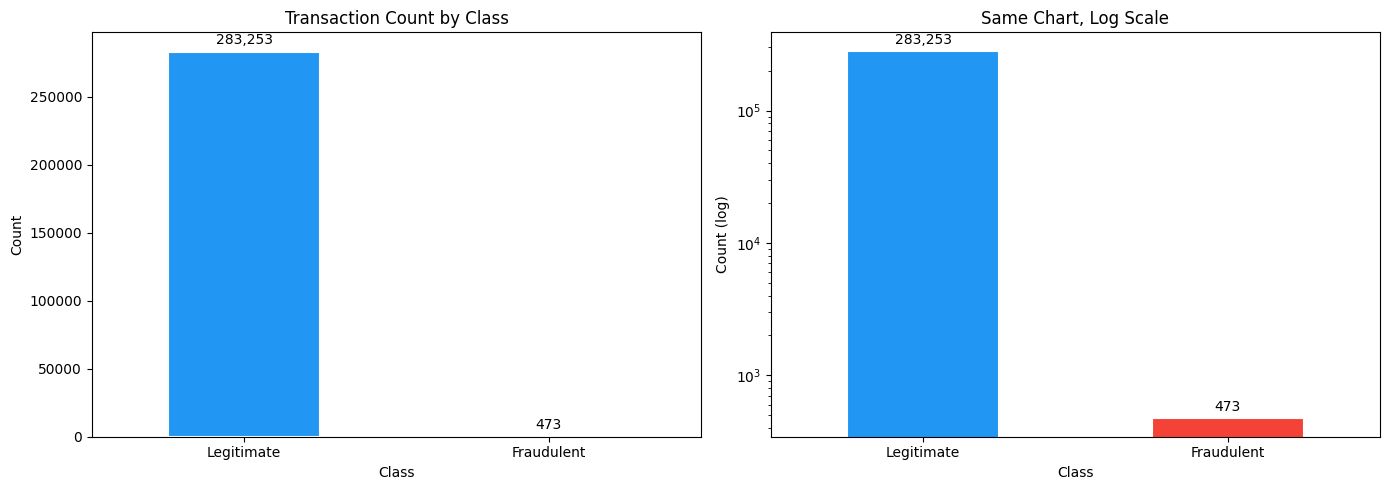

In [16]:
counts = df['Class'].value_counts()
labels = ['Legitimate', 'Fraudulent'] # Define labels for better readability

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Normal scale using pandas plot
counts.plot(kind='bar', ax=axes[0], color=[COLORS['legit'], COLORS['fraud']], edgecolor='white', linewidth=1.5)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(labels, rotation=0) # Set custom x-axis labels and prevent rotation
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}', padding=3, fontsize=10, color='black') # Add labels to bars

# Plot 2: Log scale using pandas plot
counts.plot(kind='bar', ax=axes[1], color=[COLORS['legit'], COLORS['fraud']], edgecolor='white', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_title('Same Chart, Log Scale')
axes[1].set_ylabel('Count (log)')
axes[1].set_xticklabels(labels, rotation=0) # Set custom x-axis labels and prevent rotation
axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', padding=3, fontsize=10, color='black') # Add labels to bars

plt.tight_layout()
plt.show()

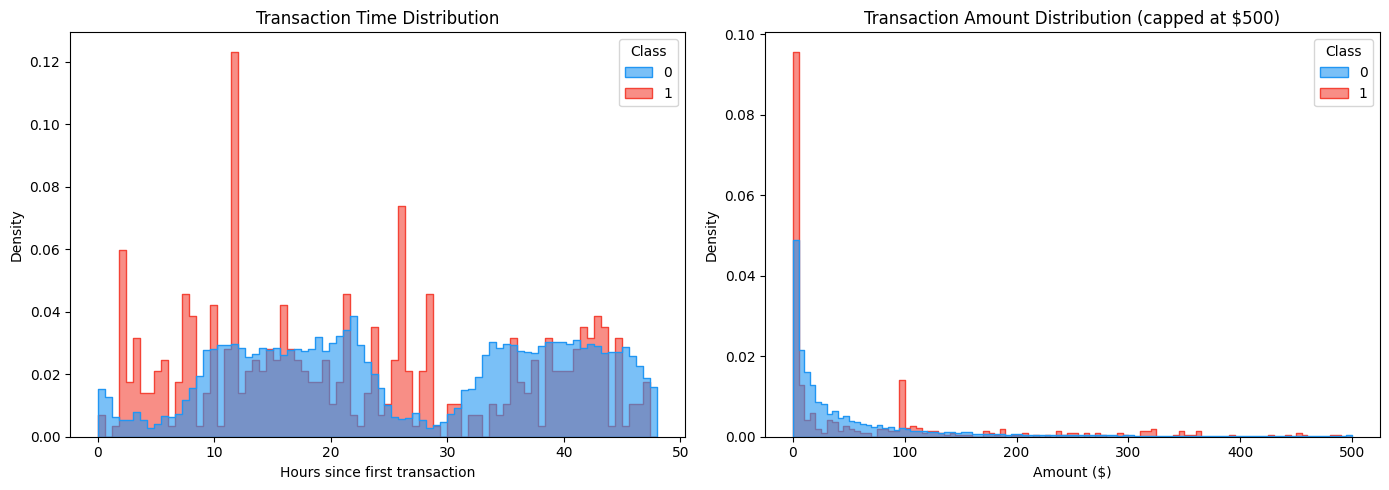

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Time Distribution (using kdeplot or histplot)
# We divide by 3600 inside the plot call
sns.histplot(data=df, x=df['Time']/3600, hue='Class', element='step',
             stat='density', common_norm=False, palette=[COLORS['legit'], COLORS['fraud']],
             bins=80, alpha=0.6, ax=axes[0])
axes[0].set_title('Transaction Time Distribution')
axes[0].set_xlabel('Hours since first transaction')

# 2. Amount Distribution
sns.histplot(data=df, x='Amount', hue='Class', element='step',
             stat='density', common_norm=False, palette=[COLORS['legit'], COLORS['fraud']],
             bins=100, binrange=(0, 500), alpha=0.6, ax=axes[1])
axes[1].set_title('Transaction Amount Distribution (capped at $500)')
axes[1].set_xlabel('Amount ($)')

plt.tight_layout()
plt.show()

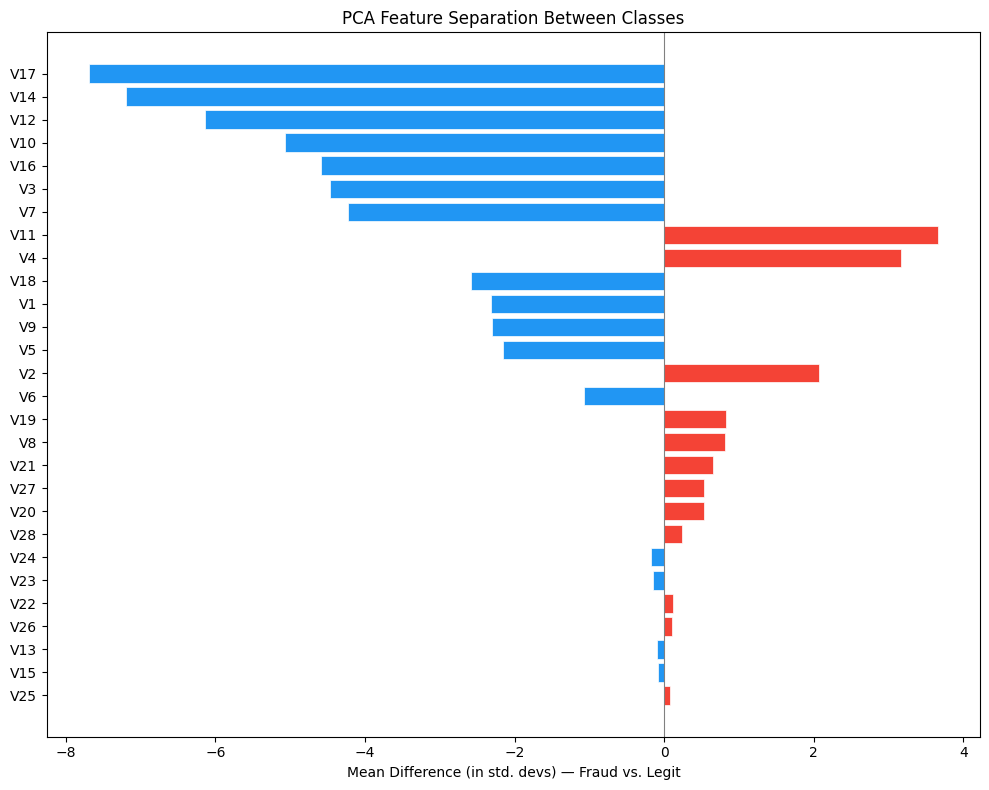

Most discriminative features: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']


In [18]:
# 1. Define columns
pca_cols = [f'V{i}' for i in range(1, 29)]

# 2. Calculate everything in one go
# Group by Class and get the mean for all V columns
means = df.groupby('Class')[pca_cols].mean()

# Subtract Fraud Mean (Class 1) from Legit Mean (Class 0)
# Note: means.loc[1] is a Series of all V-column means for Fraud
mean_diff = means.loc[1] - means.loc[0]

# Divide by the standard deviation of each column
separation_values = mean_diff / df[pca_cols].std()

# 3. Create the DataFrame and sort
sep_df = pd.DataFrame({
    'feature': pca_cols,
    'separation': separation_values,
    'abs_sep': separation_values.abs()
}).sort_values('abs_sep', ascending=True)

# 4. Plotting (Logic remains the same, but code is cleaner)
fig, ax = plt.subplots(figsize=(10, 8))
colors = [COLORS['fraud'] if s > 0 else COLORS['legit'] for s in sep_df['separation']]

ax.barh(sep_df['feature'], sep_df['separation'], color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Mean Difference (in std. devs) — Fraud vs. Legit')
ax.set_title('PCA Feature Separation Between Classes')

plt.tight_layout()
plt.show()

top_features = sep_df.nlargest(6, 'abs_sep')['feature'].tolist()
print(f'Most discriminative features: {top_features}')

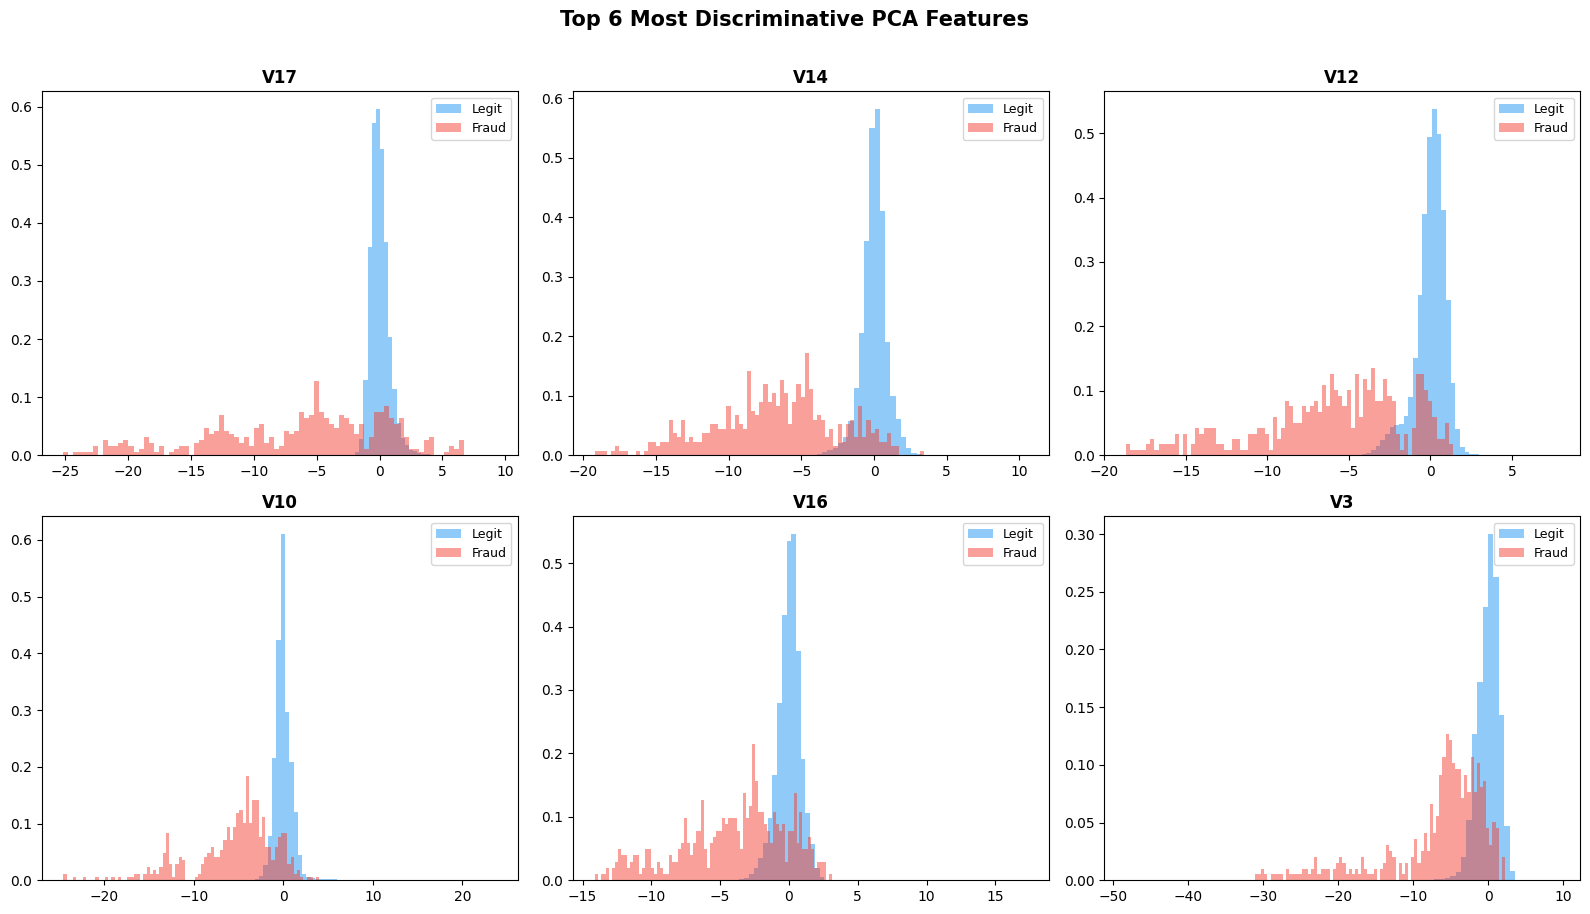

In [19]:
# Distribution plots for the top 6 most discriminative features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feat in zip(axes.ravel(), top_features):
    for label, color, name in [(0, COLORS['legit'], 'Legit'), (1, COLORS['fraud'], 'Fraud')]:
        subset = df[df['Class'] == label][feat]
        ax.hist(subset, bins=80, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Top 6 Most Discriminative PCA Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

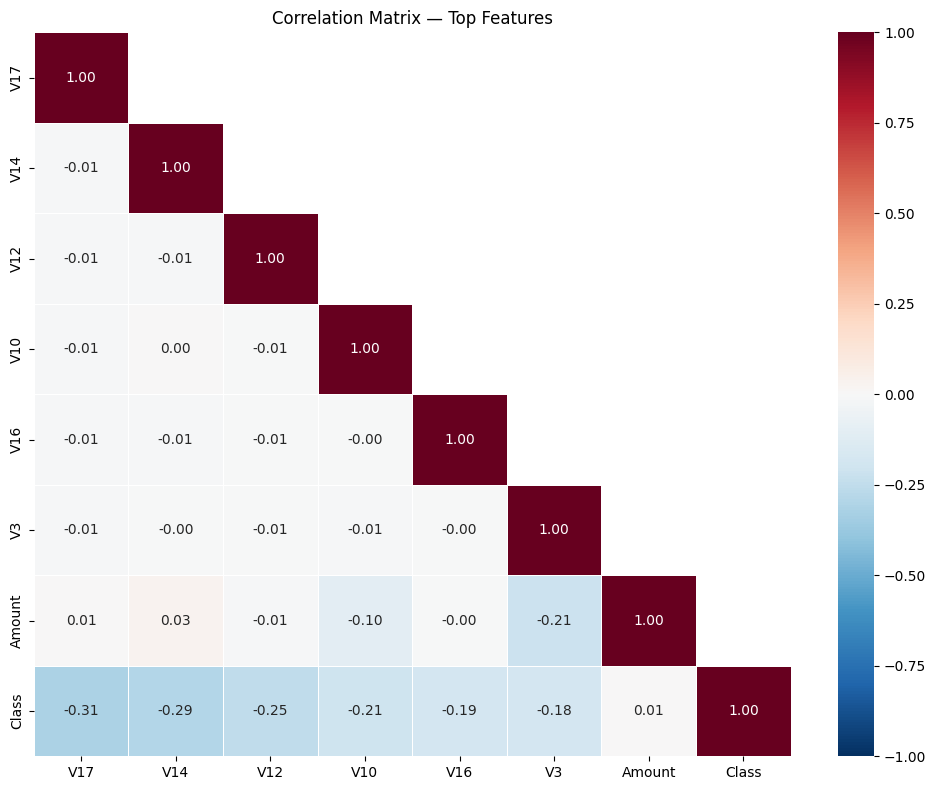

In [20]:
# Correlation heatmap for top features + Amount + Class
top_plus = top_features + ['Amount', 'Class']
corr = df[top_plus].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Top Features')
plt.tight_layout()
plt.show()

In [21]:
# compare the value for both transactions
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94835.058093,0.013439,-0.009829,0.012853,-0.010440,0.006769,0.001251,0.010447,-0.002448,0.002613,...,-0.000489,-0.00115,-0.000160,0.000360,0.000393,-0.000301,0.000065,0.001409,0.000418,88.413575
1,80450.513742,-4.498280,3.405965,-6.729599,4.472591,-2.957197,-1.432518,-5.175912,0.953255,-2.522124,...,0.405043,0.46655,0.086639,-0.096464,-0.106643,0.040615,0.050456,0.213774,0.078270,123.871860


# Under-sampling
build a sample dataset containing similar distribution of normal transactions  and Fradulent Transactions

Number of Fradulent transaction - 492

In [22]:
legal_sample = legal.sample(n=492)

In [23]:
# Concatenating two dataframes
new_df = pd.concat([legal_sample, fraud], axis=0)
new_df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
260392,159539.0,-0.219799,0.878962,0.046385,-0.814339,0.477834,-0.659181,0.829009,0.026557,0.067978,...,-0.274198,-0.626421,0.039134,-0.374470,-0.461013,0.149132,0.348480,0.139241,8.99,0
5162,4891.0,-0.851251,1.315778,1.338266,1.641240,-0.212436,-0.136012,0.223641,0.416990,0.762098,...,-0.101256,0.143780,-0.004957,0.354519,-0.119318,-0.281620,0.274702,0.127225,29.30,0
804,610.0,1.125910,-0.287398,0.779265,0.826384,-0.807977,-0.188230,-0.407289,0.010140,0.833075,...,0.068431,0.313584,-0.194061,0.110387,0.522330,0.526339,-0.005287,0.024486,59.90,0
203675,134918.0,-0.795184,0.481071,1.262961,-0.498845,0.125197,1.743589,-0.603914,1.127643,0.542584,...,0.243700,0.749664,0.098801,-0.366774,-0.741379,-0.312699,0.136581,0.107447,20.51,0
167514,118733.0,1.798773,-0.462379,-2.189639,0.261443,0.362789,-0.412364,0.108440,-0.051859,0.978738,...,-0.203813,-0.693540,-0.054896,-1.187571,-0.041865,-0.054998,-0.041393,-0.018390,138.70,0


In [24]:
new_df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94163.780488,0.055047,0.038995,-0.041302,0.007041,0.036745,-0.023407,0.104072,0.001670,-0.043221,...,-0.009386,-0.005217,-0.000262,-0.005159,-0.007929,0.030793,0.001822,-0.004105,-0.00027,85.367358
1,80450.513742,-4.498280,3.405965,-6.729599,4.472591,-2.957197,-1.432518,-5.175912,0.953255,-2.522124,...,0.405043,0.466550,0.086639,-0.096464,-0.106643,0.040615,0.050456,0.213774,0.07827,123.871860


# Split the data

In [25]:
x = new_df.drop(columns='Class', axis=1)
y = new_df['Class']

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify=y, random_state=2)


In [27]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((772, 30), (193, 30), (772,), (193,))

Model Training

In [28]:
model = LogisticRegression()

In [29]:
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [30]:
# Accuracy on training data
x_train_prediction = model.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)
print('accuracy of training data:', training_data_accuracy)


accuracy of training data: 0.939119170984456


In [31]:
x_test_prediction = model.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)
print('accuracy of test data:', test_data_accuracy)

accuracy of test data: 0.9481865284974094


In [32]:
rmodel = RandomForestClassifier()
rmodel.fit(x_train, y_train)

RandomForestClassifier()

In [33]:
rmodel_prediction = rmodel.predict(x_test)
rmodel_accuracy = accuracy_score(rmodel_prediction, y_test)
print('accuracy of test data:', rmodel_accuracy)

accuracy of test data: 0.9222797927461139


In [34]:
xgbmodel = XGBClassifier()
xgbmodel.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [35]:
xgbmodel_prediction = xgbmodel.predict(x_test)
xgbmodel_accuracy = accuracy_score(xgbmodel_prediction, y_test)
print('accuracy of test data:', xgbmodel_accuracy)

accuracy of test data: 0.927461139896373


In [37]:
model_names = ['Logistic Regression', 'RandomForest Classifier', 'XGBoost Classifier']
accuracy_scores = [test_data_accuracy, rmodel_accuracy, xgbmodel_accuracy]

performance_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': accuracy_scores
})

performance_df = performance_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

print('Model Performance Comparison:')
print(performance_df)

Model Performance Comparison:
                     Model  Test Accuracy
0      Logistic Regression       0.948187
1       XGBoost Classifier       0.927461
2  RandomForest Classifier       0.922280


# **SMOTE**
SMOTE creates synthetic fraud examples by interpolating between existing fraud samples. It's the most popular oversampling technique.

Important: SMOTE is applied ONLY to training data. Never to test data. This is a common mistake that leads to data leakage

In [38]:
 !pip install imbalanced-learn -q


In [41]:
from imblearn.over_sampling import SMOTE

SEED = 42 # Define SEED for reproducibility

# Apply SMOTE to training data only
smote = SMOTE(random_state=SEED, sampling_strategy=1.0)  # bring fraud up to 50% of legit
X_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE:  {pd.Series(y_train_smote).value_counts().to_dict()}')

rf_smote = RandomForestClassifier(n_estimators=200,max_depth=None,min_samples_leaf=1,max_features='sqrt',random_state=SEED,n_jobs=-1)

Before SMOTE: {0: 394, 1: 378}
After SMOTE:  {0: 394, 1: 394}


In [47]:
rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [45]:
rf_smote_prediction = rf_smote.predict(x_test)
rf_smote_accuracy = accuracy_score(rf_smote_prediction, y_test)
print('Accuracy of RandomForest with SMOTE on test data:', rf_smote_accuracy)

# Update the performance_df to include the SMOTE model
performance_df_smote = pd.DataFrame({
    'Model': ['Logistic Regression', 'RandomForest Classifier', 'XGBoost Classifier', 'RandomForest (SMOTE)'],
    'Test Accuracy': [test_data_accuracy, rmodel_accuracy, xgbmodel_accuracy, rf_smote_accuracy]
})

performance_df_smote = performance_df_smote.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

print('\nUpdated Model Performance Comparison:')
print(performance_df_smote)

Accuracy of RandomForest with SMOTE on test data: 0.927461139896373

Updated Model Performance Comparison:
                     Model  Test Accuracy
0      Logistic Regression       0.948187
1       XGBoost Classifier       0.927461
2     RandomForest (SMOTE)       0.927461
3  RandomForest Classifier       0.922280
